In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [7]:
#Install dependencies
!pip install -q ultralytics opencv-python-headless pandas matplotlib seaborn scikit-learn tqdm

In [8]:
# Imports and configuration
import os
import json
import random
import shutil
from pathlib import Path

import torch
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

# ---------------- CONFIGURATION ----------------
CONFIG = {
    "IMG_SIZE": 640,
    "BATCH_SIZE": 16,
    "EPOCHS": 50,
    "LEARNING_RATE": 0.01,
    "TRAIN_SPLIT": 0.8,
    "SEED": 42,
    "MODEL_ARCH": "yolov8n.pt",
    "PATIENCE": 15,
}

random.seed(CONFIG["SEED"])
np.random.seed(CONFIG["SEED"])
torch.manual_seed(CONFIG["SEED"])

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ---------------- DIRECTORIES ----------------
KAGGLE_INPUT_DIR = "/kaggle/input/datasets/julienmeine/rescue-object-detection/DRZ_rescuedataset" 
JSON_FILE = os.path.join(KAGGLE_INPUT_DIR, "/kaggle/input/datasets/julienmeine/rescue-object-detection/ann.json") 

WORKING_DIR = "/kaggle/working/yolo_dataset"
os.makedirs(WORKING_DIR, exist_ok=True)
print("Configuration loaded.")

Using device: cuda
Configuration loaded.


In [9]:
#Parse JSON, Filter ONLY 'human', Subsample, Split & Convert
import os
import json
import random
import shutil
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# ---------------- SETTINGS ----------------
MAX_HUMAN_IMAGES = 3000  # Cap total images to fit comfortably in disk memory
# ------------------------------------------

with open(JSON_FILE, "r") as f:
    coco_data = json.load(f)

# 1. Find the category ID for 'human'
human_cat_id = None
for cat in coco_data["categories"]:
    if cat["name"].lower() == "human":
        human_cat_id = cat["id"]
        break

if human_cat_id is None:
    raise ValueError("Could not find 'human' category in the dataset!")

print(f"Filtering for class 'human' (ID: {human_cat_id}) -> YOLO Class 0")

# 2. Map Images & Group ONLY valid human annotations
images = {img["id"]: img for img in coco_data["images"]}
annotations_by_image = {img_id: [] for img_id in images.keys()}

for ann in coco_data["annotations"]:
    if ann["category_id"] == human_cat_id:
        annotations_by_image[ann["image_id"]].append(ann)

# Keep ONLY images that have at least 1 human annotation
valid_human_image_ids = [
    img_id for img_id, anns in annotations_by_image.items() if len(anns) > 0
]

print(f"Found {len(valid_human_image_ids)} images containing human annotations.")

# 3. Randomly subsample if total images exceed MAX_HUMAN_IMAGES
random.seed(CONFIG["SEED"])
if len(valid_human_image_ids) > MAX_HUMAN_IMAGES:
    selected_image_ids = random.sample(valid_human_image_ids, MAX_HUMAN_IMAGES)
    print(f"Subsampled dataset to {len(selected_image_ids)} images for fast/lightweight training.")
else:
    selected_image_ids = valid_human_image_ids

# 4. Train/Val Split
train_ids, val_ids = train_test_split(
    selected_image_ids, train_size=CONFIG["TRAIN_SPLIT"], random_state=CONFIG["SEED"]
)

# 5. Create YOLO Directory Structure
for split in ["train", "val"]:
    os.makedirs(os.path.join(WORKING_DIR, "images", split), exist_ok=True)
    os.makedirs(os.path.join(WORKING_DIR, "labels", split), exist_ok=True)

def process_split(split_ids, split_name):
    print(f"Processing {split_name} split ({len(split_ids)} images)...")
    for img_id in tqdm(split_ids):
        img_info = images[img_id]
        img_filename = img_info["file_name"]
        
        src_img_path = os.path.join(KAGGLE_INPUT_DIR, "DRZ_rescuedataset", img_filename)
        if not os.path.exists(src_img_path):
            src_img_path = os.path.join(KAGGLE_INPUT_DIR, img_filename)
            
        dst_img_path = os.path.join(WORKING_DIR, "images", split_name, os.path.basename(img_filename))
        shutil.copy(src_img_path, dst_img_path)
        
        # Write YOLO label file
        label_filename = os.path.splitext(os.path.basename(img_filename))[0] + ".txt"
        label_filepath = os.path.join(WORKING_DIR, "labels", split_name, label_filename)
        
        with open(label_filepath, "w") as f:
            for ann in annotations_by_image[img_id]:
                x_min, y_min, box_w, box_h = ann["bbox"]
                img_w, img_h = img_info["width"], img_info["height"]
                
                center_x = (x_min + box_w / 2.0) / img_w
                center_y = (y_min + box_h / 2.0) / img_h
                norm_w = box_w / img_w
                norm_h = box_h / img_h
                
                center_x, center_y = max(0.0, min(1.0, center_x)), max(0.0, min(1.0, center_y))
                norm_w, norm_h = max(0.0, min(1.0, norm_w)), max(0.0, min(1.0, norm_h))
                
                f.write(f"0 {center_x:.6f} {center_y:.6f} {norm_w:.6f} {norm_h:.6f}\n")

process_split(train_ids, "train")
process_split(val_ids, "val")
print("Dataset conversion completed successfully!")

Filtering for class 'human' (ID: 3) -> YOLO Class 0
Found 10968 images containing human annotations.
Subsampled dataset to 3000 images for fast/lightweight training.
Processing train split (2400 images)...


100%|██████████| 2400/2400 [00:35<00:00, 66.83it/s] 


Processing val split (600 images)...


100%|██████████| 600/600 [00:08<00:00, 69.14it/s]

Dataset conversion completed successfully!


In [ ]:
# Generate dataset.yaml and Train YOLO
import os
from ultralytics import YOLO

# 1. Create data.yaml for YOLO training
yaml_content = f"""
path: {WORKING_DIR}
train: images/train
val: images/val

nc: 1
names: ['human']
"""

yaml_path = os.path.join(WORKING_DIR, "dataset.yaml")
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"Generated YAML configuration at: {yaml_path}")
print(yaml_content)

# 2. Load pre-trained model and train on human dataset
model = YOLO(CONFIG["MODEL_ARCH"])

train_results = model.train(
    data=yaml_path,
    epochs=CONFIG["EPOCHS"],
    imgsz=CONFIG["IMG_SIZE"],
    batch=CONFIG["BATCH_SIZE"],
    patience=CONFIG["PATIENCE"],
    lr0=CONFIG["LEARNING_RATE"],
    seed=CONFIG["SEED"],
    project="/kaggle/working/aerial_rescue_detector",
    name="yolov8_run_human_only",
    device=DEVICE,
    verbose=True
)

RUN_DIR = "/kaggle/working/aerial_rescue_detector/yolov8_run_human_only"
BEST_MODEL_PATH = os.path.join(RUN_DIR, "weights", "best.pt")

print(f"\nTraining complete!")
print(f"Best model weights saved at: {BEST_MODEL_PATH}")

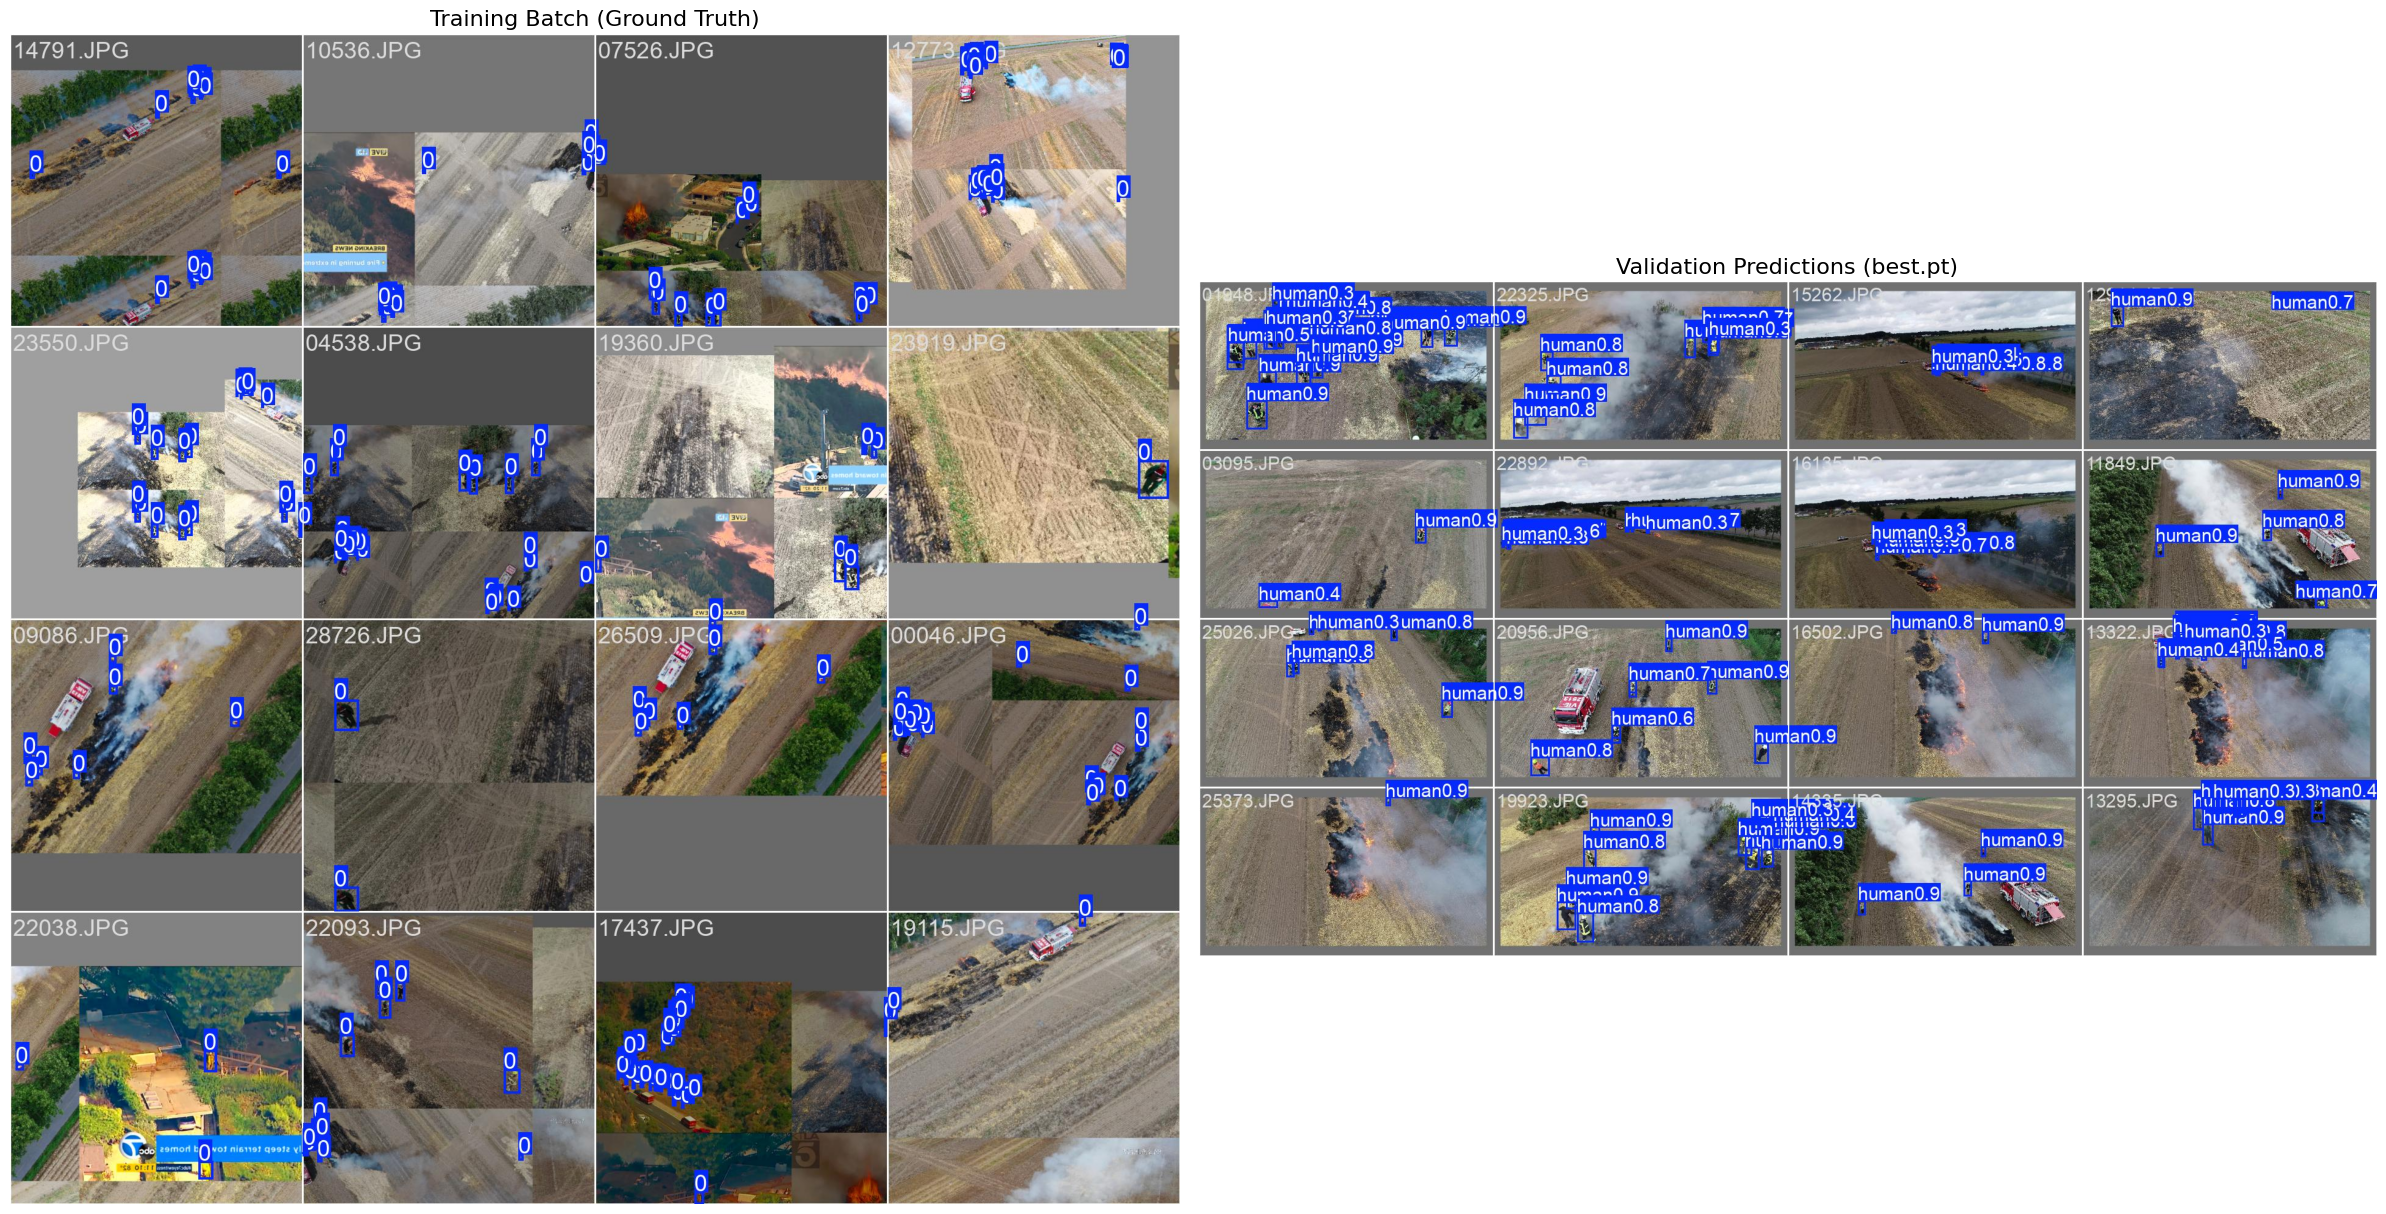

In [1]:
# Display Training vs Validation Bounding Box Predictions
import os
import matplotlib.pyplot as plt
from PIL import Image

RUN_DIR = "/kaggle/working/aerial_rescue_detector/yolov8_run_human_only"

train_batch = os.path.join(RUN_DIR, "train_batch0.jpg")
val_pred_batch = os.path.join(RUN_DIR, "val_batch0_pred.jpg")

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# 1. Ground truth training instances
if os.path.exists(train_batch):
    axes[0].imshow(Image.open(train_batch))
    axes[0].set_title("Training Batch (Ground Truth)", fontsize=16)
    axes[0].axis("off")

# 2. Validation predictions made by best.pt
if os.path.exists(val_pred_batch):
    axes[1].imshow(Image.open(val_pred_batch))
    axes[1].set_title("Validation Predictions (best.pt)", fontsize=16)
    axes[1].axis("off")

plt.tight_layout()
plt.show()

Training Performance Summary (Loss & Accuracy):


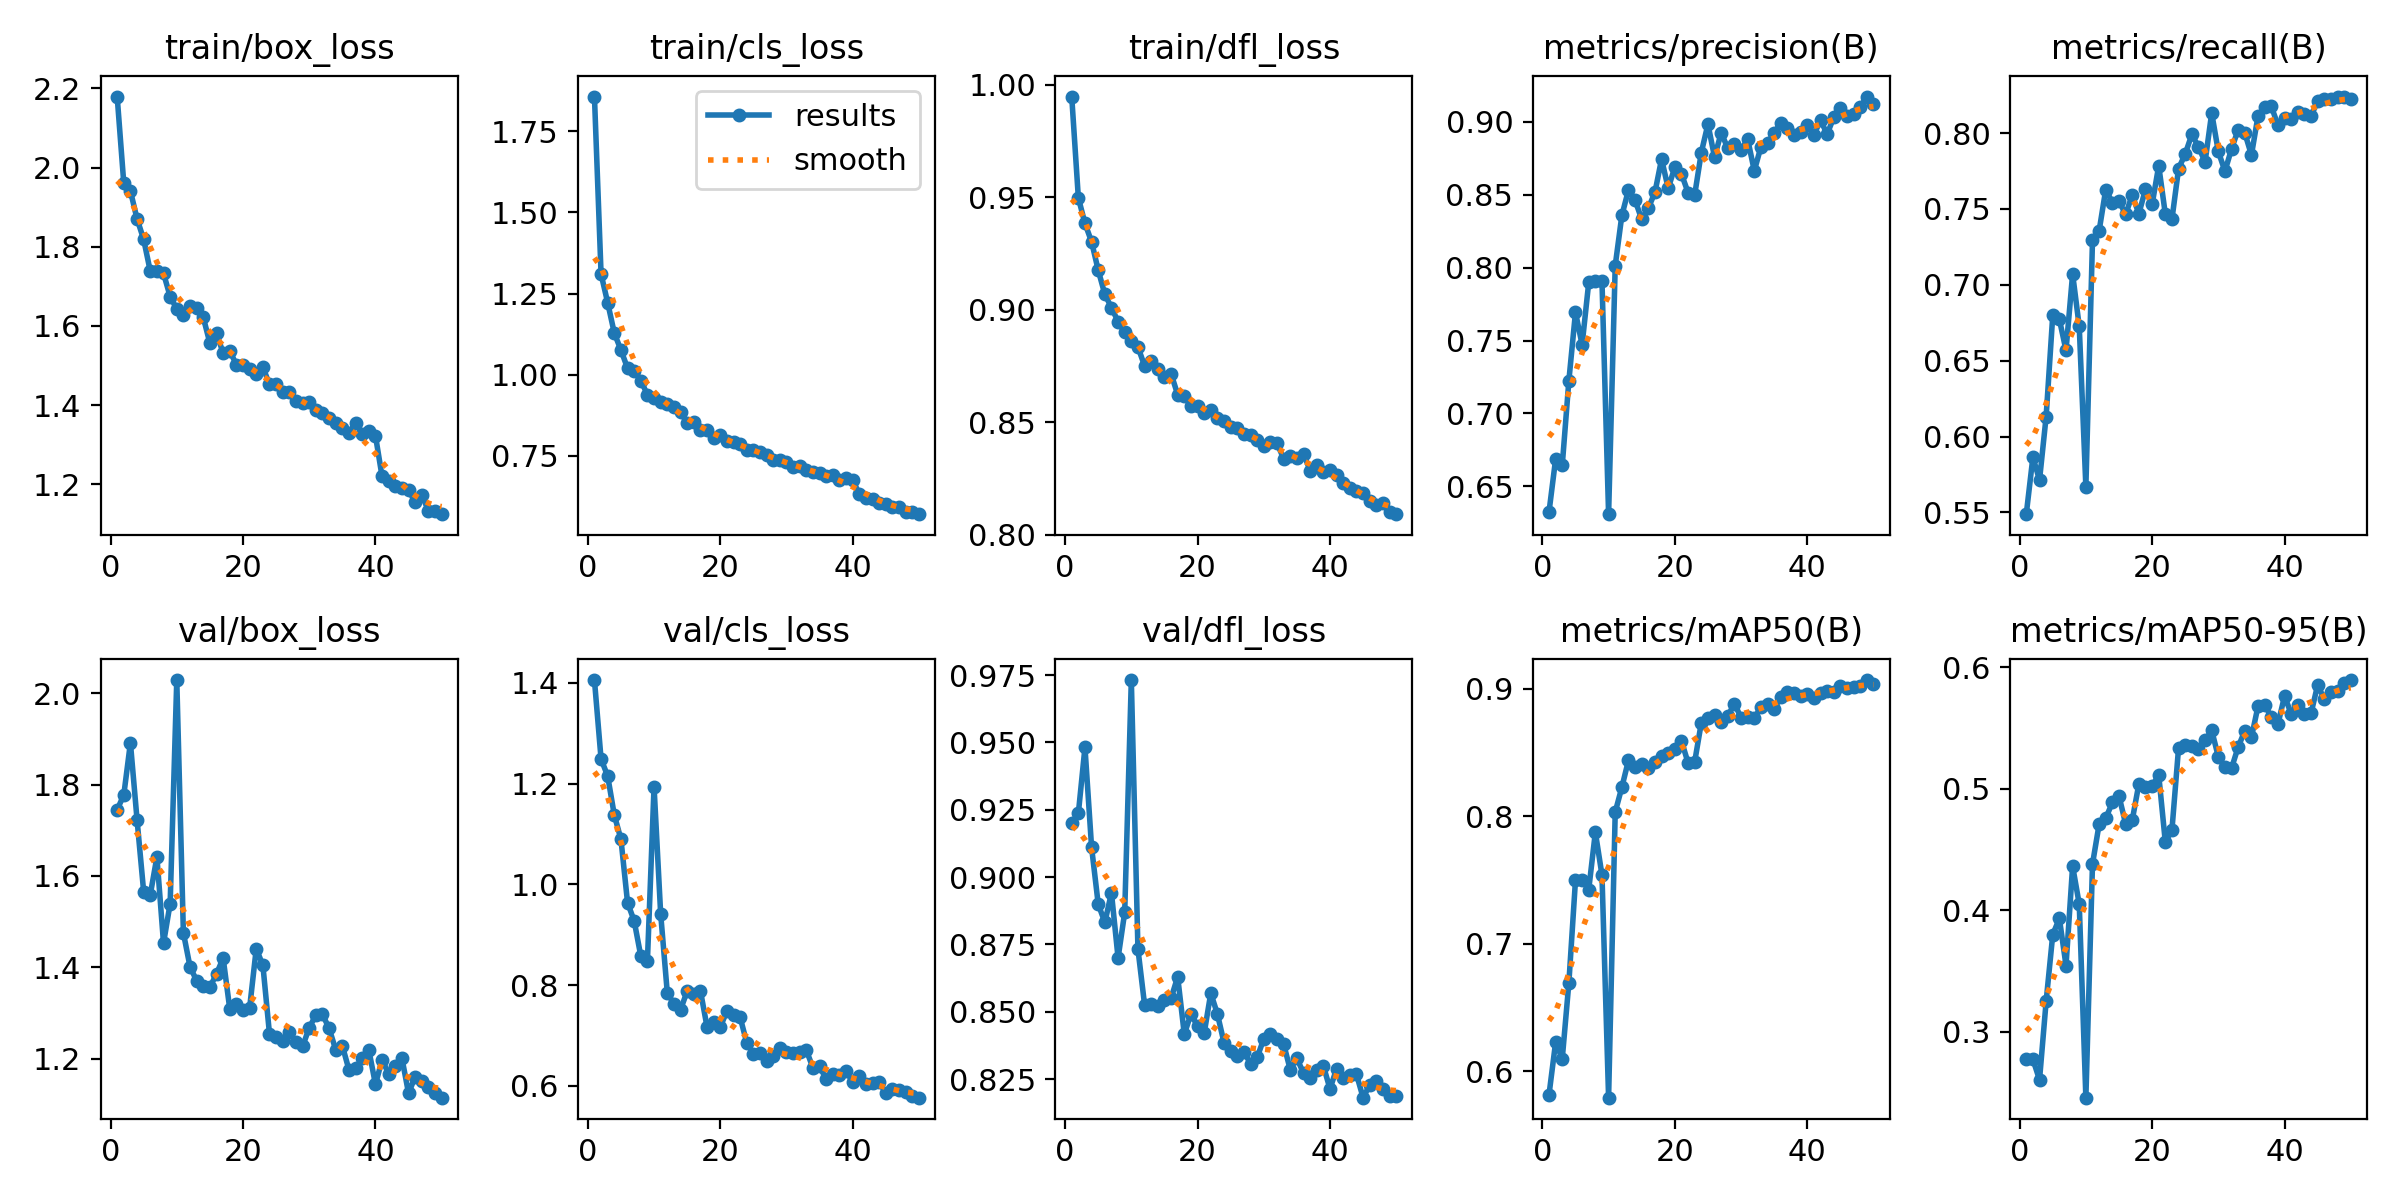

In [2]:
# Display Training Metrics Graph (results.png)
import os
from IPython.display import Image, display

results_img_path = "/kaggle/working/aerial_rescue_detector/yolov8_run_human_only/results.png"

if os.path.exists(results_img_path):
    print("Training Performance Summary (Loss & Accuracy):")
    display(Image(filename=results_img_path))
else:
    print(f"Graph not found at {results_img_path}. Check if the path is correct.")

In [2]:
# Dynamic MP4 Resolution with Memory-Safe Live Preview
import os
import glob
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from tqdm.notebook import tqdm
from ultralytics import YOLO

# 1. Automatically locate all MP4 files inside /kaggle/input/
mp4_files = glob.glob("/kaggle/input/**/*.mp4", recursive=True)

if len(mp4_files) == 0:
    print("❌ No .mp4 files found under /kaggle/input/. Verify dataset attachment.")
else:
    print(f"Found {len(mp4_files)} test video(s):")
    for f in mp4_files:
        print(f"  - {f}")
    
    # 2. Load trained model
    model_path = "/kaggle/working/aerial_rescue_detector/yolov8_run_human_only/weights/best.pt"
    model = YOLO(model_path)

    # 3. Process each video sequentially
    for video_path in mp4_files:
        filename = os.path.basename(video_path)
        output_video_path = f"/kaggle/working/annotated_{filename}"
        
        print(f"\n--- Starting inference on: {filename} ---")
        
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

        fig = plt.figure(figsize=(10, 6))

        for frame_idx in tqdm(range(total_frames), desc=f"Processing {filename}"):
            ret, frame = cap.read()
            if not ret:
                break

            results = model.predict(frame, imgsz=640, device="cuda", verbose=False)
            annotated_frame = results[0].plot() 
            
            n_humans = len(results[0].boxes)
            cv2.putText(annotated_frame, f"Humans Detected: {n_humans}", (20, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)

            writer.write(annotated_frame)
            
            # Live preview updating every 30 frames without accumulating RAM
            if frame_idx % 30 == 0 or frame_idx == total_frames - 1:
                clear_output(wait=True)
                fig.clf()
                
                ax = fig.add_subplot(111)
                ax.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
                percentage = int((frame_idx / total_frames) * 100)
                ax.set_title(f"[{filename}] {percentage}% Done | Frame {frame_idx}/{total_frames}", fontsize=12)
                ax.axis("off")
                
                display(fig)

        cap.release()
        writer.release()
        plt.close(fig)
        clear_output(wait=True)
        
        print(f"✅ Finished: {filename}")
        print(f" Saved to: {output_video_path}")
        
    print("\n All videos processed successfully! Check the /kaggle/working directory.")

✅ Finished: 13378096_3840_2160_60fps.mp4
 Saved to: /kaggle/working/annotated_13378096_3840_2160_60fps.mp4

 All videos processed successfully! Check the /kaggle/working directory.


✅ Finished: 13378096_3840_2160_60fps.mp4. Saved to: /kaggle/working/annotated_13378096_3840_2160_60fps.mp4


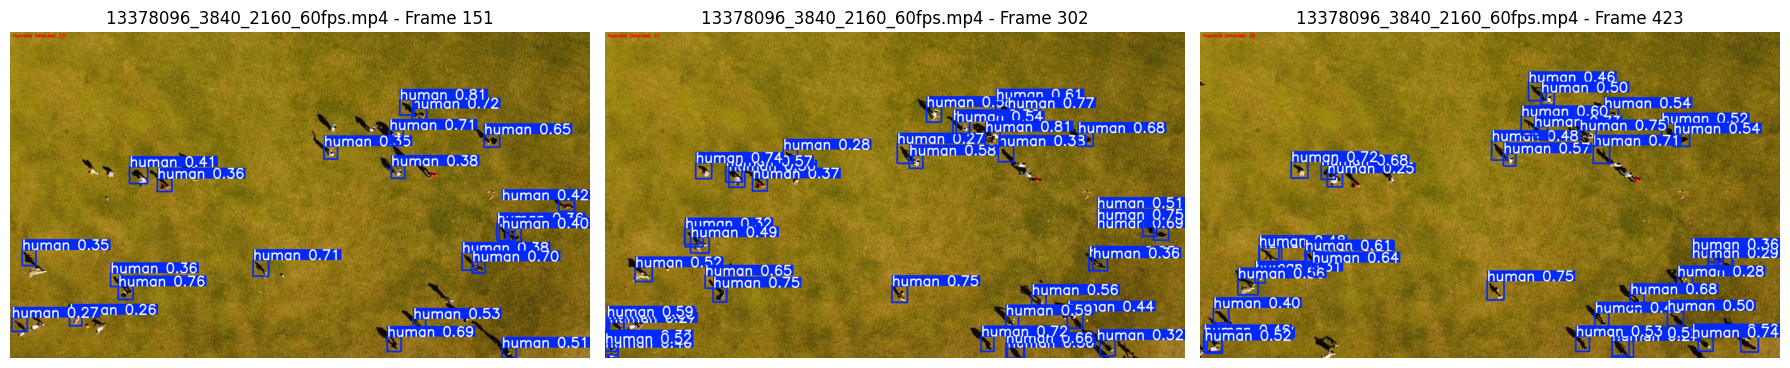

In [5]:
#Display some frames (of annotated video)
cap.release()
writer.release()
print(f"✅ Finished: {filename}. Saved to: {output_video_path}")

# --- NEW CODE TO DISPLAY FRAMES ---
import matplotlib.pyplot as plt

disp_cap = cv2.VideoCapture(output_video_path)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Grab frames at the 25%, 50%, and 70% marks of the video
frame_marks = [int(total_frames * 0.25), int(total_frames * 0.50), int(total_frames * 0.70)]

for i, frame_id in enumerate(frame_marks):
    disp_cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame = disp_cap.read()
    if ret:
        # Convert BGR (OpenCV default) to RGB (Matplotlib default) for accurate colors
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i].imshow(frame_rgb)
        axes[i].set_title(f"{filename} - Frame {frame_id}")
        axes[i].axis("off")
        
plt.tight_layout()
plt.show()
disp_cap.release()